In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import utils 
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path
import scienceplots
plt.style.use('science')

In [3]:
pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[0,0,10,1])
    brahma_control = control.control_sample_brahma(brahma_pop_Nstar10)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.2,min_N_values=10)
    


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


processing each merger redshifts for controls: 100%|██████████| 83/83 [00:02<00:00, 39.66it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:383: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 14
SM5_TNG


processing each merger redshifts for controls: 100%|██████████| 16/16 [00:00<00:00, 26.16it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:620: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 110
number of processable mergers with valid controls:
664
[22, 20, 37, 53, 95, 97, 138, 97, 48, 33, 17]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 328
number of processable mergers with valid controls:
795
[37, 40, 45, 91, 100, 105, 149, 120, 69, 21, 14]
SM5_LW10_LOWSPIN_TNG


processing each merger redshifts for controls: 100%|██████████| 17/17 [00:00<00:00, 45.29it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 80
number of processable mergers with valid controls:
405
[21, 16, 13, 29, 41, 44, 91, 59, 35, 26, 19, 11]
SM5_LW10_LOWSPIN_RICH_TNG


processing each merger redshifts for controls: 100%|██████████| 18/18 [00:00<00:00, 114.89it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 49
number of processable mergers with valid controls:
127
[12, 24, 14, 25, 12, 17, 11, 10]
[55, 57, 54, 63, 65, 57, 70, 50]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 3.8]
Brahma common zbins: [0.  0.4 1.  1.6 2.2 3.1 4.1 5.1 8.1]


In [4]:
t_delays = utils.find_merger_time_delays(sim_objs,sim_names)

In [5]:
def merger_enhancement_calc_for_mu(sim_name,sim_objs,merger_time_delay,td_threshold=0.5,quantity='sSFR',min_count=5):
    
    merger_time_delay_array = np.array(merger_time_delay[sim_name]['td'])
    small_td_mask = merger_time_delay_array <= td_threshold

    z_with_small_td = sim_objs[sim_name].z_merging_pop[small_td_mask]
    unique_zs, counts_per_z = np.unique(z_with_small_td,return_counts=True)
    filtered_unique_zs = unique_zs[counts_per_z>=min_count]
    unique_zs = filtered_unique_zs

    avg_quantity_enhancement_major = []
    std_quantity_enhancement_major = []
    avg_quantity_enhancement_minor = []
    std_quantity_enhancement_minor = []
    avg_quantity_enhancement_mini = []
    std_quantity_enhancement_mini = []

    accepted_zs = []

    for z in unique_zs:

        merging_pop_quanity_major = getattr(sim_objs[sim_name],quantity+"_merging_pop")[(sim_objs[sim_name].z_merging_pop==z) & small_td_mask & sim_objs[sim_name].major_major_merger_mask]
        control_pop_quantity_major = getattr(sim_objs[sim_name],quantity+"_control_pop")[(sim_objs[sim_name].z_control_pop==z) & small_td_mask & sim_objs[sim_name].major_major_merger_mask]
        merging_pop_quantity_minor = getattr(sim_objs[sim_name],quantity+"_merging_pop")[(sim_objs[sim_name].z_merging_pop==z) & small_td_mask & sim_objs[sim_name].minor_merger_mask]
        control_pop_quantity_minor = getattr(sim_objs[sim_name],quantity+"_control_pop")[(sim_objs[sim_name].z_control_pop==z) & small_td_mask & sim_objs[sim_name].minor_merger_mask]
        merging_pop_quantity_mini = getattr(sim_objs[sim_name],quantity+"_merging_pop")[(sim_objs[sim_name].z_merging_pop==z) & small_td_mask & sim_objs[sim_name].mini_merger_mask]
        control_pop_quantity_mini = getattr(sim_objs[sim_name],quantity+"_control_pop")[(sim_objs[sim_name].z_control_pop==z) & small_td_mask & sim_objs[sim_name].mini_merger_mask]

        if len(merging_pop_quanity_major)>=min_count and len(merging_pop_quantity_minor)>=min_count and len(merging_pop_quantity_mini)>=min_count:
            avg_quantity_enhancement_major.append(np.median(np.log10(merging_pop_quanity_major/control_pop_quantity_major)))
            std_quantity_enhancement_major.append(stats.sem(np.log10(merging_pop_quanity_major/control_pop_quantity_major)))
            avg_quantity_enhancement_minor.append(np.median(np.log10(merging_pop_quantity_minor/control_pop_quantity_minor)))
            std_quantity_enhancement_minor.append(stats.sem(np.log10(merging_pop_quantity_minor/control_pop_quantity_minor)))
            avg_quantity_enhancement_mini.append(np.median(np.log10(merging_pop_quantity_mini/control_pop_quantity_mini)))
            std_quantity_enhancement_mini.append(stats.sem(np.log10(merging_pop_quantity_mini/control_pop_quantity_mini)))
            accepted_zs.append(z)
    
    return (accepted_zs,avg_quantity_enhancement_major,std_quantity_enhancement_major,
            avg_quantity_enhancement_minor,std_quantity_enhancement_minor,
            avg_quantity_enhancement_mini,std_quantity_enhancement_mini)


In [6]:
merger_enhancement_calc_for_mu('TNG50',sim_objs,t_delays,td_threshold=3,quantity='sSFR',min_count=5)

([1.4140982203725216, 2.5772902716018935, 3.008131071630377],
 [0.22090048289887346, 0.2624548171688924, 0.23165252021298555],
 [0.26384939514706995, 0.12426647926945349, 0.069572794806299],
 [0.13491026432940445, 0.10005975270443454, 0.16750148872523024],
 [0.19754869751253465, 0.08319382444483003, 0.2415864854063751],
 [0.06001792133948239, 0.08067310525675446, 0.25416205336450337],
 [0.29287647258842586, 0.05959412626591324, 0.1031633557607785])

In [7]:
merger_enhancement_calc_for_mu('SM5_DFD_3_TNG',sim_objs,t_delays,td_threshold=1,quantity='sSFR',min_count=5)

/tmp/ipykernel_495907/3339631931.py:32: RuntimeWarning: divide by zero encountered in divide
  avg_quantity_enhancement_minor.append(np.median(np.log10(merging_pop_quantity_minor/control_pop_quantity_minor)))
/tmp/ipykernel_495907/3339631931.py:33: RuntimeWarning: divide by zero encountered in divide
  std_quantity_enhancement_minor.append(stats.sem(np.log10(merging_pop_quantity_minor/control_pop_quantity_minor)))
/blue/lblecha/pranavsatheesh/.conda/envs/hfrl/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_495907/3339631931.py:34: RuntimeWarning: divide by zero encountered in divide
  avg_quantity_enhancement_mini.append(np.median(np.log10(merging_pop_quantity_mini/control_pop_quantity_mini)))
/tmp/ipykernel_495907/3339631931.py:34: RuntimeWarning: divide by zero encountered in log10
  avg_quantity_enhancement_mini.append(np.median(np.log10(merging_pop_quantity_mini/control_pop

([3.008131071630377, 4.0079451114652676, 4.995933468164624],
 [0.20962133547073533, 0.07531399182332557, 0.07303852293208385],
 [0.05232485518923565, 0.060705488173279094, 0.06825141921971631],
 [0.12820431648710984, 0.054315129980602866, 0.11609167427286905],
 [nan, nan, 0.10212174662372518],
 [0.11878127685695025, 0.11301807593925373, 0.163080935716856],
 [nan, 0.04804017616306933, 0.06907564370638752])

In [8]:
def merger_enhancement_calc_for_small_td(sim_name,sim_objs,merger_time_delay,td_threshold=0.5,quantity='sSFR',min_count=5):
    
    merger_time_delay_array = np.array(merger_time_delay[sim_name]['td'])
    small_td_mask = merger_time_delay_array < td_threshold

    z_with_small_td = sim_objs[sim_name].z_merging_pop[small_td_mask]
    unique_zs, counts_per_z = np.unique(z_with_small_td,return_counts=True)
    filtered_unique_zs = unique_zs[counts_per_z>=min_count]
    unique_zs = filtered_unique_zs

    avg_quantity_enhancement = []
    std_quantity_enhancement = []

    for z in unique_zs:
        if quantity == 'fgas':
            merging_pop_quantity = getattr(sim_objs[sim_name],'fgas_progs')[(sim_objs[sim_name].z_merging_pop==z) & small_td_mask]
            control_pop_quantity = getattr(sim_objs[sim_name],'fgas_control')[(sim_objs[sim_name].z_merging_pop==z) & small_td_mask]
        else:
            merging_pop_quantity = getattr(sim_objs[sim_name],quantity+"_merging_pop")[(sim_objs[sim_name].z_merging_pop==z) & small_td_mask]
            control_pop_quantity = getattr(sim_objs[sim_name],quantity+"_control_pop")[(sim_objs[sim_name].z_merging_pop==z) & small_td_mask]

        quantity_enhancement = []
        for i in range(len(control_pop_quantity)):
            if control_pop_quantity[i]>0 and merging_pop_quantity[i]>0:
                quantity_enhancement.append(np.log10(merging_pop_quantity[i]/control_pop_quantity[i]))
        
        avg_quantity_enhancement.append(np.mean(quantity_enhancement))
        std_quantity_enhancement.append(np.std(quantity_enhancement)/np.sqrt(len(quantity_enhancement)))
    avg_quantity_enhancement = np.array(avg_quantity_enhancement)
    std_quantity_enhancement = np.array(std_quantity_enhancement) 
    

In [9]:
# ...existing code...
def merger_enhancement_calc_for_mu(sim_obj,quantity,z_start,zbin,zend=4,Nmin=10,log=True):

    z_bins = []
    avg_quantity_enhancement_major = []
    std_quantity_enhancement_major = []
    avg_quantity_enhancement_minor = []
    std_quantity_enhancement_minor = []
    avg_quantity_enhancement_mini = []
    std_quantity_enhancement_mini = []

    z_next = z_start
    z_bins.append(z_start)
    while True:
        merger_z_mask = (sim_obj.z_merging_pop >= z_next) & (sim_obj.z_merging_pop < (z_next + zbin))
        major_merger_z_mask = sim_obj.major_major_merger_mask & merger_z_mask
        minor_merger_z_mask = sim_obj.minor_merger_mask & merger_z_mask
        mini_merger_z_mask  = sim_obj.mini_merger_mask & merger_z_mask

        if np.sum(major_merger_z_mask) >= Nmin and np.sum(minor_merger_z_mask) >= Nmin and np.sum(mini_merger_z_mask) >= Nmin:
            z_next = z_next + zbin
            z_bins.append(z_next)
            if log == True:
                quantity_log_enhancement_major = []
                quantity_log_enhancement_minor = []
                quantity_log_enhancement_mini = []

                for i in range(len(sim_obj.z_merging_pop[major_merger_z_mask])):
                    merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[major_merger_z_mask][i]
                    control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[major_merger_z_mask][i]
                    if control_pop_quantity>0 and merging_pop_quantity>0:
                        quantity_log_enhancement_major.append(np.log10(merging_pop_quantity/control_pop_quantity))
                avg_quantity_enhancement_major.append(np.median(quantity_log_enhancement_major))
                std_quantity_enhancement_major.append(stats.sem(quantity_log_enhancement_major))

                for i in range(len(sim_obj.z_merging_pop[minor_merger_z_mask])):
                    merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[minor_merger_z_mask][i]
                    control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[minor_merger_z_mask][i]
                    if control_pop_quantity>0 and merging_pop_quantity>0:
                        quantity_log_enhancement_minor.append(np.log10(merging_pop_quantity/control_pop_quantity))
                avg_quantity_enhancement_minor.append(np.median(quantity_log_enhancement_minor))
                std_quantity_enhancement_minor.append(stats.sem(quantity_log_enhancement_minor))

                for i in range(len(sim_obj.z_merging_pop[mini_merger_z_mask])):
                    merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[mini_merger_z_mask][i]
                    control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[mini_merger_z_mask][i]
                    if control_pop_quantity>0 and merging_pop_quantity>0:
                        quantity_log_enhancement_mini.append(np.log10(merging_pop_quantity/control_pop_quantity))
                avg_quantity_enhancement_mini.append(np.median(quantity_log_enhancement_mini))
                std_quantity_enhancement_mini.append(stats.sem(quantity_log_enhancement_mini))
            else:
                quantity_enhancement = []
                for i in range(len(sim_obj.z_merging_pop[merger_z_mask])):
                    merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[merger_z_mask][i]
                    control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[merger_z_mask][i]
                    quantity_enhancement.append(merging_pop_quantity - control_pop_quantity)
                avg_quantity_enhancement.append(np.median(quantity_enhancement))
                std_quantity_enhancement.append(stats.sem(quantity_enhancement))

        else:
            z_next = z_next + zbin
        if z_next >= zend:
            break

    return z_bins,avg_quantity_enhancement_major,std_quantity_enhancement_major,avg_quantity_enhancement_minor,std_quantity_enhancement_minor,avg_quantity_enhancement_mini,std_quantity_enhancement_mini
# ...existing code...

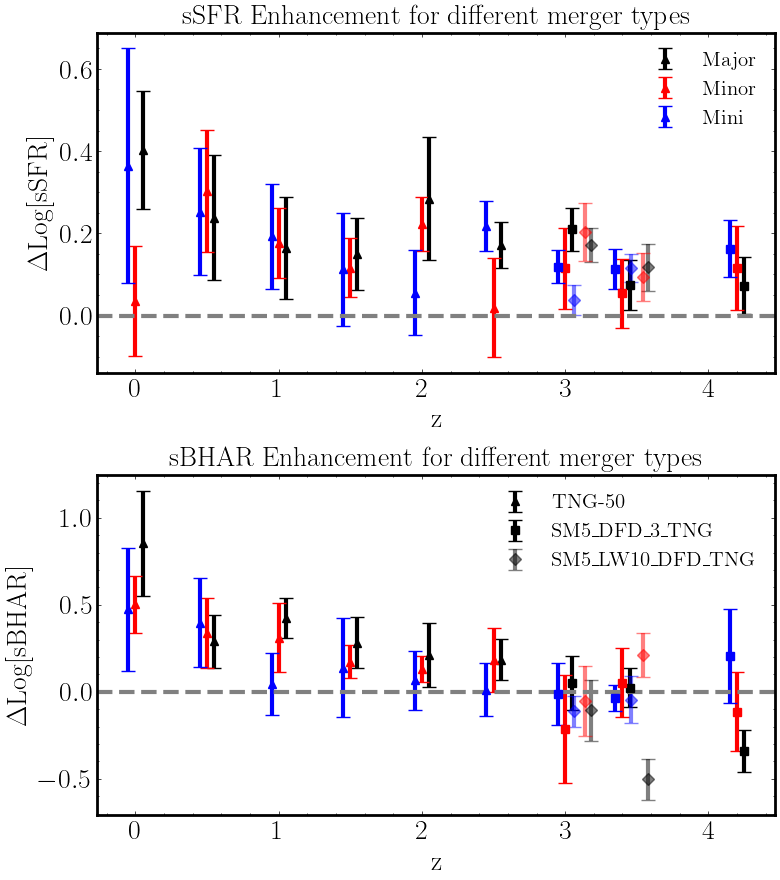

In [10]:
hostplot.set_plot_style(linewidth=3, titlesize=20,labelsize=20,xlabelsize=20,ylabelsize=20,legendsize=15)
fig,ax = plt.subplots(2,1,figsize=(8,9))
sim_markers = {'TNG50': '^','SM5_DFD_3_TNG': 's','SM5_LW10_DFD_3_TNG': 'D','SM5_TNG': 'o','SM5_LW10_TNG': '+'}

z_bins_TNG50,avg_sSFR_major_TNG50,std_sSFR_major_TNG50,avg_sSFR_minor_TNG50,std_sSFR_minor_TNG50,avg_sSFR_mini_TNG50,std_sSFR_mini_TNG50 = merger_enhancement_calc_for_mu(sim_objs['TNG50'],'sSFR',log=True,z_start=0,zbin=0.5,zend=4,Nmin=10)
z_offset = 0.05
ax[0].errorbar(np.array(z_bins_TNG50[:-1])+z_offset,avg_sSFR_major_TNG50,yerr=std_sSFR_major_TNG50,fmt=sim_markers['TNG50'],color='black',label='Major',capsize=5)
ax[0].errorbar(np.array(z_bins_TNG50[:-1]),avg_sSFR_minor_TNG50,yerr=std_sSFR_minor_TNG50,fmt=sim_markers['TNG50'],color='red',label='Minor',capsize=5)
ax[0].errorbar(np.array(z_bins_TNG50[:-1])-z_offset,avg_sSFR_mini_TNG50,yerr=std_sSFR_mini_TNG50,fmt=sim_markers['TNG50'],color='blue',label='Mini',capsize=5)

z_bins_SM5_DFD_3_TNG,avg_sSFR_major_SM5_DFD_3_TNG,std_sSFR_major_SM5_DFD_3_TNG,avg_sSFR_minor_SM5_DFD_3_TNG,std_sSFR_minor_SM5_DFD_3_TNG,avg_sSFR_mini_SM5_DFD_3_TNG,std_sSFR_mini_SM5_DFD_3_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_DFD_3_TNG'],'sSFR',log=True,z_start=3,zbin=0.4,zend=10,Nmin=5)
z_offset = 0.05
ax[0].errorbar(np.array(z_bins_SM5_DFD_3_TNG[:-1])+z_offset,avg_sSFR_major_SM5_DFD_3_TNG,yerr=std_sSFR_major_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='black',capsize=5)
ax[0].errorbar(np.array(z_bins_SM5_DFD_3_TNG[:-1]),avg_sSFR_minor_SM5_DFD_3_TNG,yerr=std_sSFR_minor_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='red',capsize=5)
ax[0].errorbar(np.array(z_bins_SM5_DFD_3_TNG[:-1])-z_offset,avg_sSFR_mini_SM5_DFD_3_TNG,yerr=std_sSFR_mini_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='blue',capsize=5)

z_bins_SM5_LW10_DFD_3_TNG,avg_sSFR_major_SM5_LW10_DFD_3_TNG,std_sSFR_major_SM5_LW10_DFD_3_TNG,avg_sSFR_minor_SM5_LW10_DFD_3_TNG,std_sSFR_minor_SM5_LW10_DFD_3_TNG,avg_sSFR_mini_SM5_LW10_DFD_3_TNG,std_sSFR_mini_SM5_LW10_DFD_3_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_LW10_DFD_3_TNG'],'sSFR',log=True,z_start=3,zbin=0.4,zend=10,Nmin=5)
z_offset = 0.04
z_global_offset = 0.1
ax[0].errorbar(np.array(z_bins_SM5_LW10_DFD_3_TNG[:-1])+z_global_offset+2*z_offset,avg_sSFR_major_SM5_LW10_DFD_3_TNG,yerr=std_sSFR_major_SM5_LW10_DFD_3_TNG,fmt=sim_markers['SM5_LW10_DFD_3_TNG'],color='black',capsize=5,alpha=0.5)
ax[0].errorbar(np.array(z_bins_SM5_LW10_DFD_3_TNG[:-1])+z_global_offset+z_offset,avg_sSFR_minor_SM5_LW10_DFD_3_TNG,yerr=std_sSFR_minor_SM5_LW10_DFD_3_TNG,fmt=sim_markers['SM5_LW10_DFD_3_TNG'],color='red',capsize=5,alpha=0.5)
ax[0].errorbar(np.array(z_bins_SM5_LW10_DFD_3_TNG[:-1])+z_global_offset-z_offset,avg_sSFR_mini_SM5_LW10_DFD_3_TNG,yerr=std_sSFR_mini_SM5_LW10_DFD_3_TNG,fmt=sim_markers['SM5_LW10_DFD_3_TNG'],color='blue',capsize=5,alpha=0.5)

ax[0].set_xlabel('z')
ax[0].axhline(0,ls='--',color='grey')
ax[0].set_ylabel(r'$\Delta \rm Log [sSFR]$')
ax[0].set_title('sSFR Enhancement for different merger types')
ax[0].legend()

z_bins_TNG50,avg_sBHAR_major_TNG50,std_sBHAR_major_TNG50,avg_sBHAR_minor_TNG50,std_sBHAR_minor_TNG50,avg_sBHAR_mini_TNG50,std_sBHAR_mini_TNG50 = merger_enhancement_calc_for_mu(sim_objs['TNG50'],'sBHAR',log=True,z_start=0,zbin=0.5,zend=4,Nmin=10)
z_offset = 0.05
ax[1].errorbar(np.array(z_bins_TNG50[:-1])+z_offset,avg_sBHAR_major_TNG50,yerr=std_sBHAR_major_TNG50,fmt=sim_markers['TNG50'],color='black',label='TNG-50',capsize=5)
ax[1].errorbar(np.array(z_bins_TNG50[:-1]),avg_sBHAR_minor_TNG50,yerr=std_sBHAR_minor_TNG50,fmt=sim_markers['TNG50'],color='red',capsize=5)
ax[1].errorbar(np.array(z_bins_TNG50[:-1])-z_offset,avg_sBHAR_mini_TNG50,yerr=std_sBHAR_mini_TNG50,fmt=sim_markers['TNG50'],color='blue',capsize=5)

z_bins_SM5_DFD_3_TNG,avg_sBHAR_major_SM5_DFD_3_TNG,std_sBHAR_major_SM5_DFD_3_TNG,avg_sBHAR_minor_SM5_DFD_3_TNG,std_sBHAR_minor_SM5_DFD_3_TNG,avg_sBHAR_mini_SM5_DFD_3_TNG,std_sBHAR_mini_SM5_DFD_3_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_DFD_3_TNG'],'sBHAR',log=True,z_start=3,zbin=0.4,zend=10,Nmin=5)
z_offset = 0.05
ax[1].errorbar(np.array(z_bins_SM5_DFD_3_TNG[:-1])+z_offset,avg_sBHAR_major_SM5_DFD_3_TNG,yerr=std_sBHAR_major_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='black',label='SM5_DFD_3_TNG',capsize=5)
ax[1].errorbar(np.array(z_bins_SM5_DFD_3_TNG[:-1]),avg_sBHAR_minor_SM5_DFD_3_TNG,yerr=std_sBHAR_minor_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='red',capsize=5)
ax[1].errorbar(np.array(z_bins_SM5_DFD_3_TNG[:-1])-z_offset,avg_sBHAR_mini_SM5_DFD_3_TNG,yerr=std_sBHAR_mini_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='blue',capsize=5) 

z_bins_SM5_LW10_DFD_3_TNG,avg_sBHAR_major_SM5_LW10_DFD_3_TNG,std_sBHAR_major_SM5_LW10_DFD_3_TNG,avg_sBHAR_minor_SM5_LW10_DFD_3_TNG,std_sBHAR_minor_SM5_LW10_DFD_3_TNG,avg_sBHAR_mini_SM5_LW10_DFD_3_TNG,std_sBHAR_mini_SM5_LW10_DFD_3_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_LW10_DFD_3_TNG'],'sBHAR',log=True,z_start=3,zbin=0.4,zend=10,Nmin=10)
z_offset = 0.04
z_global_offset = 0.1
ax[1].errorbar(np.array(z_bins_SM5_LW10_DFD_3_TNG[:-1])+z_global_offset+2*z_offset,avg_sBHAR_major_SM5_LW10_DFD_3_TNG,yerr=std_sBHAR_major_SM5_LW10_DFD_3_TNG,fmt=sim_markers['SM5_LW10_DFD_3_TNG'],color='black',label='SM5_LW10_DFD_TNG',capsize=5,alpha=0.5)
ax[1].errorbar(np.array(z_bins_SM5_LW10_DFD_3_TNG[:-1])+z_global_offset+z_offset,avg_sBHAR_minor_SM5_LW10_DFD_3_TNG,yerr=std_sBHAR_minor_SM5_LW10_DFD_3_TNG,fmt=sim_markers['SM5_LW10_DFD_3_TNG'],color='red',capsize=5,alpha=0.5)
ax[1].errorbar(np.array(z_bins_SM5_LW10_DFD_3_TNG[:-1])+z_global_offset-z_offset,avg_sBHAR_mini_SM5_LW10_DFD_3_TNG,yerr=std_sBHAR_mini_SM5_LW10_DFD_3_TNG,fmt=sim_markers['SM5_LW10_DFD_3_TNG'],color='blue',capsize=5,alpha=0.5)


ax[1].set_xlabel('z')
ax[1].axhline(0,ls='--',color='grey')
ax[1].set_ylabel(r'$\Delta \rm Log[sBHAR] $')
ax[1].set_title('sBHAR Enhancement for different merger types')
ax[1].legend()
fig.tight_layout()
fig.savefig("../../figures/merger_enhancement_vs_redshift_for_different_merger_types_TNG50_BRAHMA.pdf")

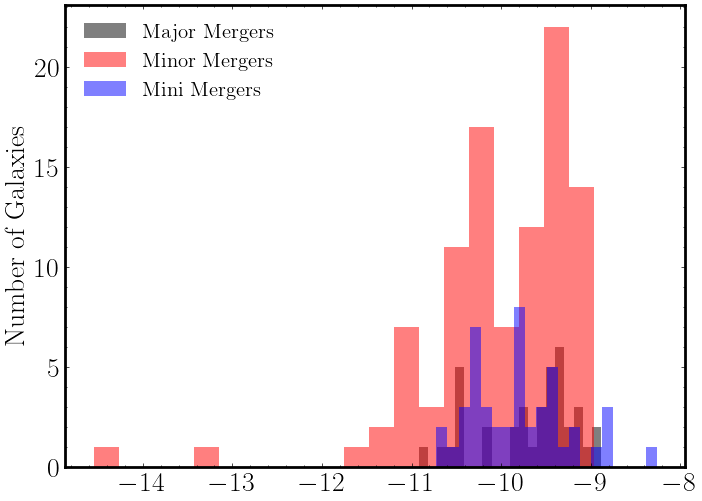

In [11]:
TNG50_low_z_mask = (sim_objs['TNG50'].z_merging_pop>=0)&(sim_objs['TNG50'].z_merging_pop<=1)
TNG50_low_z_minor_merger_mask = sim_objs['TNG50'].minor_merger_mask & TNG50_low_z_mask
TNG50_low_z_mini_merger_mask = sim_objs['TNG50'].mini_merger_mask & TNG50_low_z_mask
TNG50_low_z_major_merger_mask = sim_objs['TNG50'].major_major_merger_mask & TNG50_low_z_mask

#plot the sSFR distribution for major, minor and mini mergers in TNG50 for low z
hostplot.set_plot_style(linewidth=3, titlesize=20,labelsize=20,xlabelsize=20,ylabelsize=20,legendsize=15)
fig,ax = plt.subplots(figsize=(8,6))
ax.hist(np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_major_merger_mask]),bins=20,alpha=0.5,label='Major Mergers',color='black')
ax.hist(np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_minor_merger_mask]),bins=20,alpha=0.5,label='Minor Mergers',color='red')
ax.hist(np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask]),bins=20,alpha=0.5,label='Mini Mergers',color='blue')
ax.set_ylabel('Number of Galaxies')
ax.legend()

/tmp/ipykernel_495907/354965358.py:5: RuntimeWarning: divide by zero encountered in log10
  sSFR_control_pop_lowz_mini = np.log10(sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask])


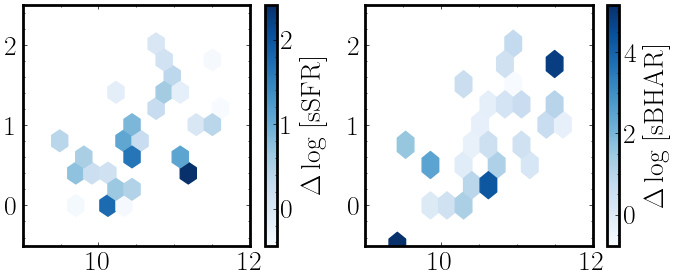

In [12]:
Mstar_lowz_mini = np.log10(sim_objs['TNG50'].Mstar_merging_pop[TNG50_low_z_mini_merger_mask])
SFR_lowz_mini = np.log10(sim_objs['TNG50'].SFR_merging_pop[TNG50_low_z_mini_merger_mask])

sSFR_merging_pop_lowz_mini = np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask])
sSFR_control_pop_lowz_mini = np.log10(sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask])
sSFR_log_enhancement_lowz_mini = sSFR_merging_pop_lowz_mini - sSFR_control_pop_lowz_mini
valid = np.isfinite(sSFR_log_enhancement_lowz_mini)

fig,ax = plt.subplots(1,2,figsize=(7,3))
hb = ax[0].hexbin(Mstar_lowz_mini[valid],SFR_lowz_mini[valid],C= sSFR_log_enhancement_lowz_mini, gridsize=10,cmap='Blues',mincnt=1)
ax[0].set_xlim(9,12)
ax[0].set_ylim(-0.5,2.5)
cb = plt.colorbar(hb,ax=ax[0])
cb.set_label(r"$\Delta \log$ [sSFR]")

sBHAR_merging_pop_lowz_mini = np.log10(sim_objs['TNG50'].sBHAR_merging_pop[TNG50_low_z_mini_merger_mask])
sBHAR_control_pop_lowz_mini = np.log10(sim_objs['TNG50'].sBHAR_control_pop[TNG50_low_z_mini_merger_mask])
sBHAR_log_enhancement_lowz_mini = sBHAR_merging_pop_lowz_mini - sBHAR_control_pop_lowz_mini
valid = np.isfinite(sBHAR_log_enhancement_lowz_mini)
hb = ax[1].hexbin(Mstar_lowz_mini[valid],SFR_lowz_mini[valid],C= sBHAR_log_enhancement_lowz_mini, gridsize=10,cmap='Blues',mincnt=1)
ax[1].set_xlim(9,12)
ax[1].set_ylim(-0.5,2.5)
cb = plt.colorbar(hb,ax=ax[1])
cb.set_label(r"$\Delta \log$ [sBHAR]")


fig.tight_layout()

/tmp/ipykernel_495907/322225567.py:8: RuntimeWarning: divide by zero encountered in log10
  sSFR_control_pop_lowz_mini = np.log10(sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask])


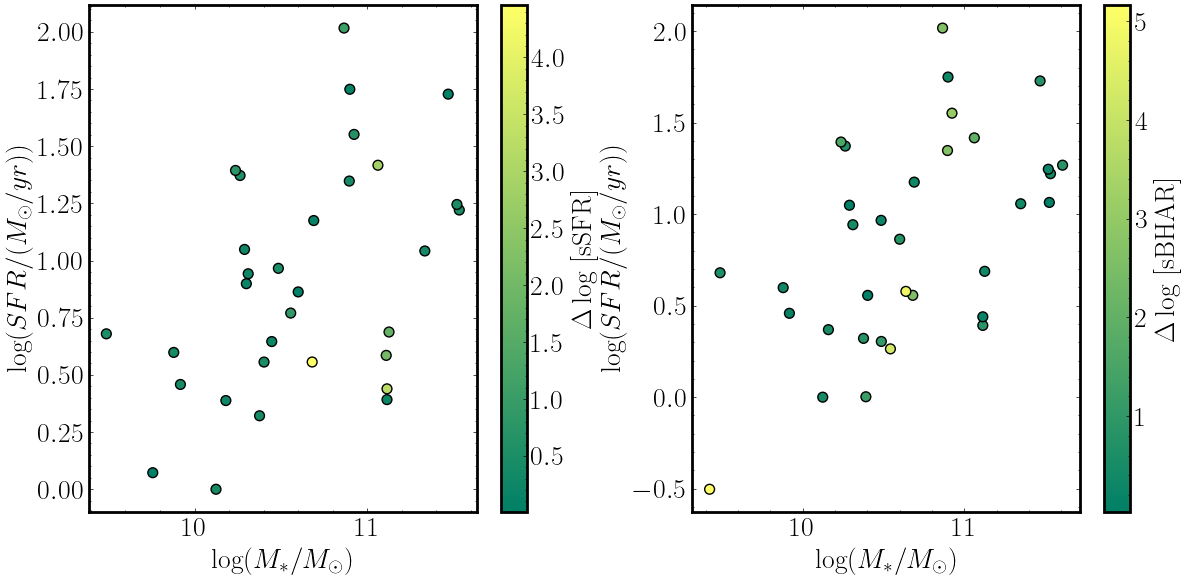

In [38]:
fig,axes = plt.subplots(1,2,figsize=(12,6))

Mstar_lowz_mini = np.log10(sim_objs['TNG50'].Mstar_merging_pop[TNG50_low_z_mini_merger_mask])
SFR_lowz_mini = np.log10(sim_objs['TNG50'].SFR_merging_pop[TNG50_low_z_mini_merger_mask])


sSFR_merging_pop_lowz_mini = np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask])
sSFR_control_pop_lowz_mini = np.log10(sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask])
sSFR_log_enhancement_lowz_mini = sSFR_merging_pop_lowz_mini - sSFR_control_pop_lowz_mini
valid = np.isfinite(sSFR_log_enhancement_lowz_mini)&(sSFR_log_enhancement_lowz_mini>=0)
#valid = np.isfinite(sSFR_log_enhancement_lowz_mini)&(sSFR_log_enhancement_lowz_mini>=0)

sSFR_log_enhancement_lowz_mini = sSFR_log_enhancement_lowz_mini[valid]
Mstar_lowz_mini = Mstar_lowz_mini[valid]
SFR_lowz_mini = SFR_lowz_mini[valid]    

scatter = axes[0].scatter(Mstar_lowz_mini,SFR_lowz_mini,c=sSFR_log_enhancement_lowz_mini,cmap='summer',s=50,edgecolor='k')
axes[0].set_xlabel(r'$\log(M_*/M_\odot)$')
axes[0].set_ylabel(r'$\log(SFR/(M_\odot/yr))$')
cb = plt.colorbar(scatter,ax=axes[0])
cb.set_label(r"$\Delta \log$ [sSFR]")   

Mstar_lowz_mini = np.log10(sim_objs['TNG50'].Mstar_merging_pop[TNG50_low_z_mini_merger_mask])
SFR_lowz_mini = np.log10(sim_objs['TNG50'].SFR_merging_pop[TNG50_low_z_mini_merger_mask])

sBHAR_merging_pop_lowz_mini = np.log10(sim_objs['TNG50'].sBHAR_merging_pop[TNG50_low_z_mini_merger_mask])
sBHAR_control_pop_lowz_mini = np.log10(sim_objs['TNG50'].sBHAR_control_pop[TNG50_low_z_mini_merger_mask])
sBHAR_log_enhancement_lowz_mini = sBHAR_merging_pop_lowz_mini - sBHAR_control_pop_lowz_mini
valid = np.isfinite(sBHAR_log_enhancement_lowz_mini)&(sBHAR_log_enhancement_lowz_mini>=0)
sBHAR_log_enhancement_lowz_mini = sBHAR_log_enhancement_lowz_mini[valid]
Mstar_lowz_mini = Mstar_lowz_mini[valid]
SFR_lowz_mini = SFR_lowz_mini[valid]

scatter = axes[1].scatter(Mstar_lowz_mini,SFR_lowz_mini,c=sBHAR_log_enhancement_lowz_mini,cmap='summer',s=50,edgecolor='k')
axes[1].set_xlabel(r'$\log(M_*/M_\odot)$')
axes[1].set_ylabel(r'$\log(SFR/(M_\odot/yr))$')
cb = plt.colorbar(scatter,ax=axes[1])
cb.set_label(r"$\Delta \log$ [sBHAR]")

fig.tight_layout()


/tmp/ipykernel_177259/2753083768.py:5: RuntimeWarning: divide by zero encountered in divide
  enhancement = np.log10(sSFR_merging / sSFR_control)
/blue/lblecha/pranavsatheesh/.conda/envs/hfrl/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


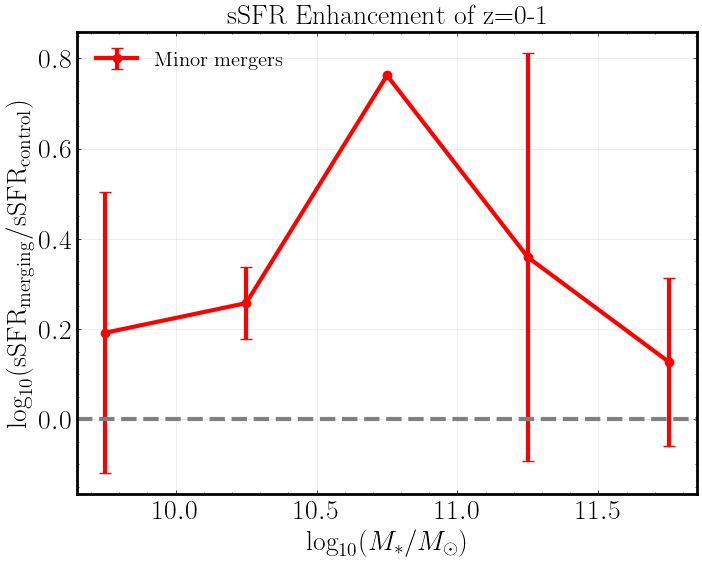

In [26]:

# Get stellar mass and sSFR enhancement
stellar_mass = np.log10(sim_objs['TNG50'].Mstar_merging_pop[TNG50_low_z_mini_merger_mask])  # adjust field if needed
sSFR_merging = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask]
sSFR_control = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask]
enhancement = np.log10(sSFR_merging / sSFR_control)

# Define stellar mass bins
mass_bins = np.arange(9, 12.5, 0.5)
bin_centers = (mass_bins[:-1] + mass_bins[1:]) / 2
median_enh = []
std_enh = []

for i in range(len(mass_bins)-1):
    in_bin = (stellar_mass >= mass_bins[i]) & (stellar_mass < mass_bins[i+1])
    if np.sum(in_bin) > 0:
        median_enh.append(np.median(enhancement[in_bin]))
        std_enh.append(np.std(enhancement[in_bin]) / np.sqrt(np.sum(in_bin)))
    else:
        median_enh.append(np.nan)
        std_enh.append(np.nan)

plt.figure(figsize=(8,6))
plt.errorbar(bin_centers, median_enh, yerr=std_enh, fmt='o-', color='red', capsize=4, label='Minor mergers')
plt.axhline(0, ls='--', color='grey')
plt.xlabel(r'$\log_{10}(M_*/M_\odot)$')
plt.ylabel(r'$\log_{10}(\mathrm{sSFR}_{\mathrm{merging}}/\mathrm{sSFR}_{\mathrm{control}})$')
plt.title('sSFR Enhancement of z=0-1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_177259/426300626.py:5: RuntimeWarning: divide by zero encountered in divide
  enhancement_major = np.log10(sSFR_merging_major / sSFR_control_major)
/tmp/ipykernel_177259/426300626.py:10: RuntimeWarning: divide by zero encountered in divide
  enhancement_minor = np.log10(sSFR_merging_minor / sSFR_control_minor)
/tmp/ipykernel_177259/426300626.py:15: RuntimeWarning: divide by zero encountered in divide
  enhancement_mini = np.log10(sSFR_merging_mini / sSFR_control_mini)
/blue/lblecha/pranavsatheesh/.conda/envs/hfrl/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


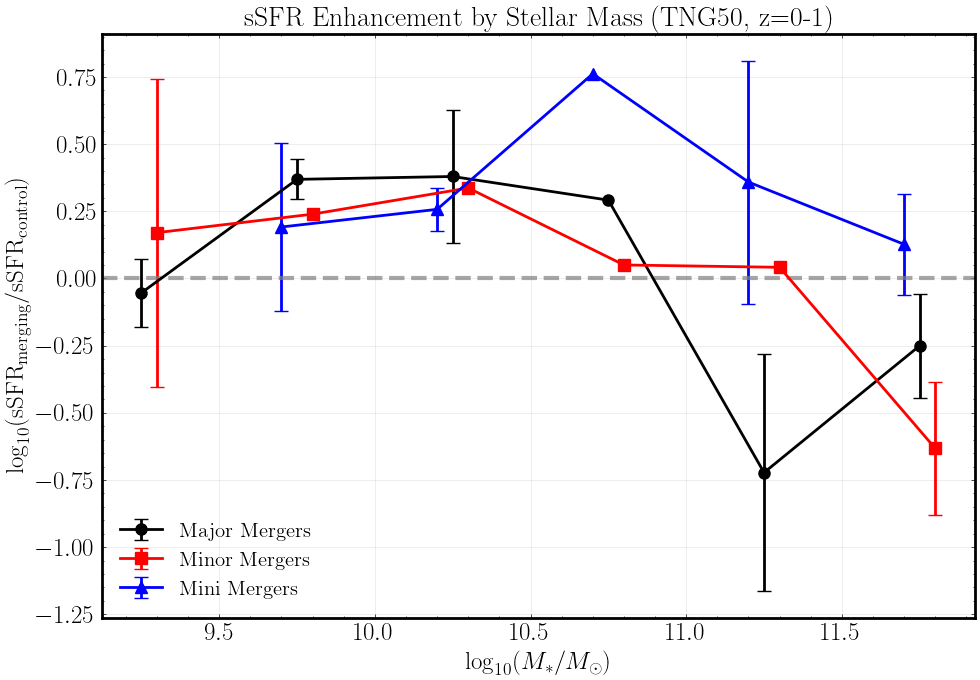

In [27]:
# Get stellar mass and sSFR enhancement for all three merger types
stellar_mass_major = np.log10(sim_objs['TNG50'].Mstar_merging_pop[TNG50_low_z_major_merger_mask])
sSFR_merging_major = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_major_merger_mask]
sSFR_control_major = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_major_merger_mask]
enhancement_major = np.log10(sSFR_merging_major / sSFR_control_major)

stellar_mass_minor = np.log10(sim_objs['TNG50'].Mstar_merging_pop[TNG50_low_z_minor_merger_mask])
sSFR_merging_minor = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_minor_merger_mask]
sSFR_control_minor = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_minor_merger_mask]
enhancement_minor = np.log10(sSFR_merging_minor / sSFR_control_minor)

stellar_mass_mini = np.log10(sim_objs['TNG50'].Mstar_merging_pop[TNG50_low_z_mini_merger_mask])
sSFR_merging_mini = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask]
sSFR_control_mini = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask]
enhancement_mini = np.log10(sSFR_merging_mini / sSFR_control_mini)

# Define stellar mass bins
mass_bins = np.arange(9, 12.5, 0.5)
bin_centers = (mass_bins[:-1] + mass_bins[1:]) / 2

# Function to compute median enhancement in mass bins
def compute_enhancement_by_mass(stellar_mass, enhancement, mass_bins):
    median_enh = []
    std_enh = []
    for i in range(len(mass_bins)-1):
        in_bin = (stellar_mass >= mass_bins[i]) & (stellar_mass < mass_bins[i+1])
        if np.sum(in_bin) > 0:
            median_enh.append(np.median(enhancement[in_bin]))
            std_enh.append(np.std(enhancement[in_bin]) / np.sqrt(np.sum(in_bin)))
        else:
            median_enh.append(np.nan)
            std_enh.append(np.nan)
    return np.array(median_enh), np.array(std_enh)

median_major, std_major = compute_enhancement_by_mass(stellar_mass_major, enhancement_major, mass_bins)
median_minor, std_minor = compute_enhancement_by_mass(stellar_mass_minor, enhancement_minor, mass_bins)
median_mini, std_mini = compute_enhancement_by_mass(stellar_mass_mini, enhancement_mini, mass_bins)

# Plot
hostplot.set_plot_style(linewidth=3, titlesize=20, labelsize=18, xlabelsize=18, ylabelsize=18, legendsize=15)
fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(bin_centers, median_major, yerr=std_major, fmt='o-', color='black', capsize=5, label='Major Mergers', linewidth=2, markersize=8)
ax.errorbar(bin_centers + 0.05, median_minor, yerr=std_minor, fmt='s-', color='red', capsize=5, label='Minor Mergers', linewidth=2, markersize=8)
ax.errorbar(bin_centers - 0.05, median_mini, yerr=std_mini, fmt='^-', color='blue', capsize=5, label='Mini Mergers', linewidth=2, markersize=8)

ax.axhline(0, ls='--', color='grey', alpha=0.7)
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$', fontsize=18)
ax.set_ylabel(r'$\log_{10}(\mathrm{sSFR}_{\mathrm{merging}}/\mathrm{sSFR}_{\mathrm{control}})$', fontsize=18)
ax.set_title('sSFR Enhancement by Stellar Mass (TNG50, z=0-1)', fontsize=20)
ax.legend(fontsize=15)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

/tmp/ipykernel_177259/1553021511.py:5: RuntimeWarning: divide by zero encountered in divide
  enhancement_major = np.log10(sSFR_merging_major / sSFR_control_major)
/tmp/ipykernel_177259/1553021511.py:10: RuntimeWarning: divide by zero encountered in divide
  enhancement_minor = np.log10(sSFR_merging_minor / sSFR_control_minor)
/tmp/ipykernel_177259/1553021511.py:15: RuntimeWarning: divide by zero encountered in divide
  enhancement_mini = np.log10(sSFR_merging_mini / sSFR_control_mini)
/blue/lblecha/pranavsatheesh/.conda/envs/hfrl/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


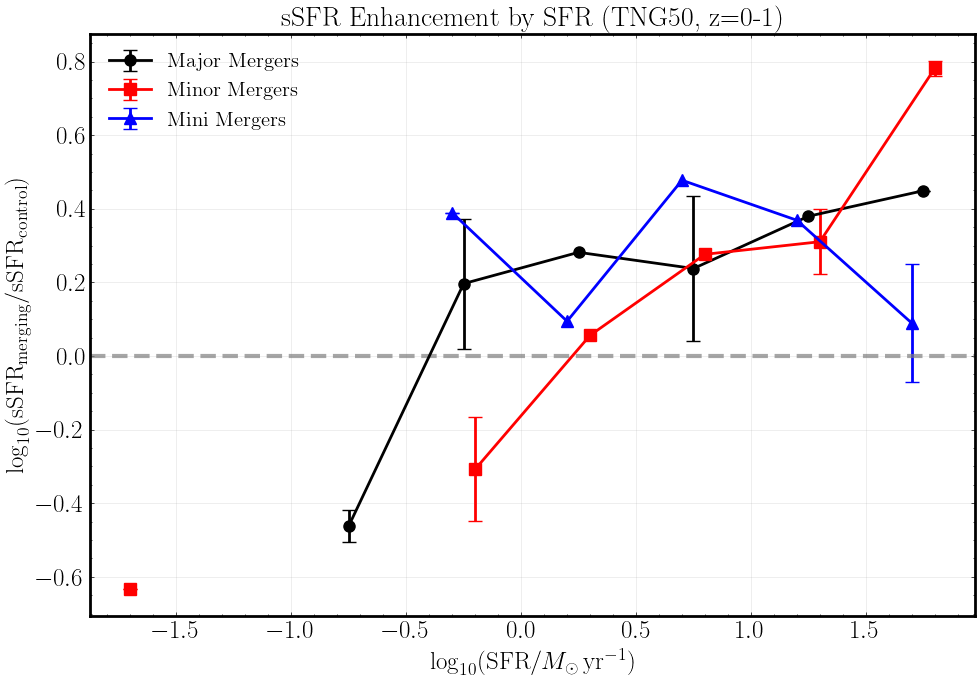

In [28]:
# Get SFR and sSFR enhancement for all three merger types
SFR_major = np.log10(sim_objs['TNG50'].SFR_merging_pop[TNG50_low_z_major_merger_mask])
sSFR_merging_major = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_major_merger_mask]
sSFR_control_major = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_major_merger_mask]
enhancement_major = np.log10(sSFR_merging_major / sSFR_control_major)

SFR_minor = np.log10(sim_objs['TNG50'].SFR_merging_pop[TNG50_low_z_minor_merger_mask])
sSFR_merging_minor = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_minor_merger_mask]
sSFR_control_minor = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_minor_merger_mask]
enhancement_minor = np.log10(sSFR_merging_minor / sSFR_control_minor)

SFR_mini = np.log10(sim_objs['TNG50'].SFR_merging_pop[TNG50_low_z_mini_merger_mask])
sSFR_merging_mini = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask]
sSFR_control_mini = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask]
enhancement_mini = np.log10(sSFR_merging_mini / sSFR_control_mini)

# Define SFR bins
sfr_bins = np.arange(-3, 2.5, 0.5)
bin_centers = (sfr_bins[:-1] + sfr_bins[1:]) / 2

# Function to compute median enhancement in SFR bins
def compute_enhancement_by_sfr(sfr, enhancement, sfr_bins):
    median_enh = []
    std_enh = []
    for i in range(len(sfr_bins)-1):
        in_bin = (sfr >= sfr_bins[i]) & (sfr < sfr_bins[i+1])
        if np.sum(in_bin) > 0:
            median_enh.append(np.median(enhancement[in_bin]))
            std_enh.append(np.std(enhancement[in_bin]) / np.sqrt(np.sum(in_bin)))
        else:
            median_enh.append(np.nan)
            std_enh.append(np.nan)
    return np.array(median_enh), np.array(std_enh)

median_major, std_major = compute_enhancement_by_sfr(SFR_major, enhancement_major, sfr_bins)
median_minor, std_minor = compute_enhancement_by_sfr(SFR_minor, enhancement_minor, sfr_bins)
median_mini, std_mini = compute_enhancement_by_sfr(SFR_mini, enhancement_mini, sfr_bins)

# Plot
hostplot.set_plot_style(linewidth=3, titlesize=20, labelsize=18, xlabelsize=18, ylabelsize=18, legendsize=15)
fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(bin_centers, median_major, yerr=std_major, fmt='o-', color='black', capsize=5, label='Major Mergers', linewidth=2, markersize=8)
ax.errorbar(bin_centers + 0.05, median_minor, yerr=std_minor, fmt='s-', color='red', capsize=5, label='Minor Mergers', linewidth=2, markersize=8)
ax.errorbar(bin_centers - 0.05, median_mini, yerr=std_mini, fmt='^-', color='blue', capsize=5, label='Mini Mergers', linewidth=2, markersize=8)

ax.axhline(0, ls='--', color='grey', alpha=0.7)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$', fontsize=18)
ax.set_ylabel(r'$\log_{10}(\mathrm{sSFR}_{\mathrm{merging}}/\mathrm{sSFR}_{\mathrm{control}})$', fontsize=18)
ax.set_title('sSFR Enhancement by SFR (TNG50, z=0-1)', fontsize=20)
ax.legend(fontsize=15)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

/tmp/ipykernel_177259/567264264.py:5: RuntimeWarning: divide by zero encountered in divide
  enhancement_major = np.log10(sSFR_merging_major / sSFR_control_major)
/tmp/ipykernel_177259/567264264.py:10: RuntimeWarning: divide by zero encountered in divide
  enhancement_minor = np.log10(sSFR_merging_minor / sSFR_control_minor)
/tmp/ipykernel_177259/567264264.py:15: RuntimeWarning: divide by zero encountered in divide
  enhancement_mini = np.log10(sSFR_merging_mini / sSFR_control_mini)
/blue/lblecha/pranavsatheesh/.conda/envs/hfrl/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


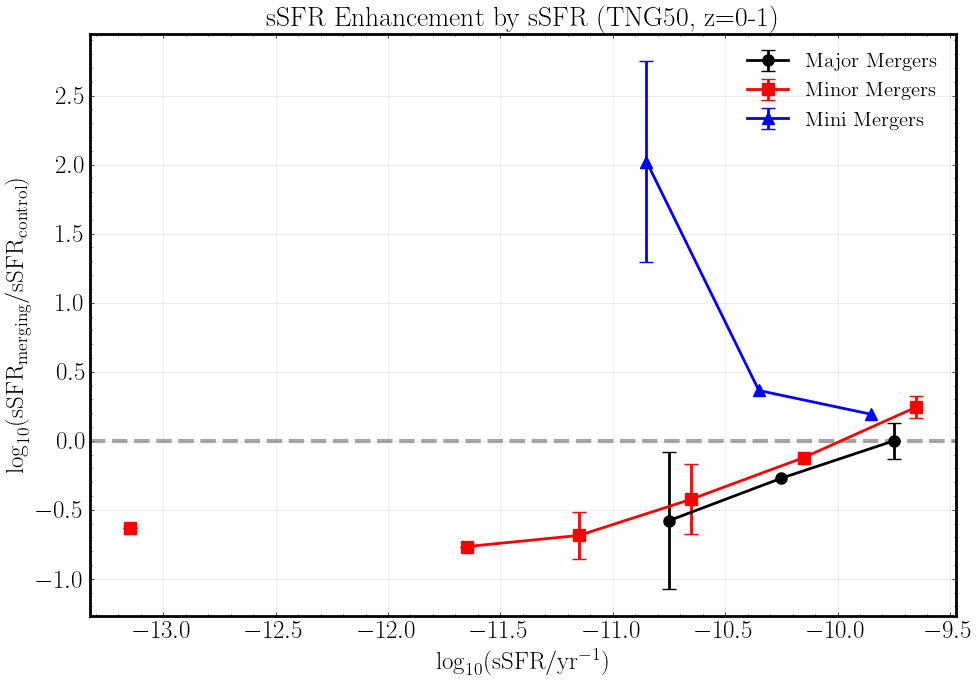

In [29]:
# Get sSFR and sSFR enhancement for all three merger types
sSFR_major = np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_major_merger_mask])
sSFR_merging_major = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_major_merger_mask]
sSFR_control_major = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_major_merger_mask]
enhancement_major = np.log10(sSFR_merging_major / sSFR_control_major)

sSFR_minor = np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_minor_merger_mask])
sSFR_merging_minor = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_minor_merger_mask]
sSFR_control_minor = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_minor_merger_mask]
enhancement_minor = np.log10(sSFR_merging_minor / sSFR_control_minor)

sSFR_mini = np.log10(sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask])
sSFR_merging_mini = sim_objs['TNG50'].sSFR_merging_pop[TNG50_low_z_mini_merger_mask]
sSFR_control_mini = sim_objs['TNG50'].sSFR_control_pop[TNG50_low_z_mini_merger_mask]
enhancement_mini = np.log10(sSFR_merging_mini / sSFR_control_mini)

# Define sSFR bins
ssfr_bins = np.arange(-14, -9, 0.5)
bin_centers = (ssfr_bins[:-1] + ssfr_bins[1:]) / 2

# Function to compute median enhancement in sSFR bins
def compute_enhancement_by_ssfr(ssfr, enhancement, ssfr_bins):
    median_enh = []
    std_enh = []
    for i in range(len(ssfr_bins)-1):
        in_bin = (ssfr >= ssfr_bins[i]) & (ssfr < ssfr_bins[i+1])
        if np.sum(in_bin) > 0:
            median_enh.append(np.median(enhancement[in_bin]))
            std_enh.append(np.std(enhancement[in_bin]) / np.sqrt(np.sum(in_bin)))
        else:
            median_enh.append(np.nan)
            std_enh.append(np.nan)
    return np.array(median_enh), np.array(std_enh)

median_major, std_major = compute_enhancement_by_ssfr(sSFR_major, enhancement_major, ssfr_bins)
median_minor, std_minor = compute_enhancement_by_ssfr(sSFR_minor, enhancement_minor, ssfr_bins)
median_mini, std_mini = compute_enhancement_by_ssfr(sSFR_mini, enhancement_mini, ssfr_bins)

# Plot
hostplot.set_plot_style(linewidth=3, titlesize=20, labelsize=18, xlabelsize=18, ylabelsize=18, legendsize=15)
fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(bin_centers, median_major, yerr=std_major, fmt='o-', color='black', capsize=5, label='Major Mergers', linewidth=2, markersize=8)
ax.errorbar(bin_centers + 0.1, median_minor, yerr=std_minor, fmt='s-', color='red', capsize=5, label='Minor Mergers', linewidth=2, markersize=8)
ax.errorbar(bin_centers - 0.1, median_mini, yerr=std_mini, fmt='^-', color='blue', capsize=5, label='Mini Mergers', linewidth=2, markersize=8)

ax.axhline(0, ls='--', color='grey', alpha=0.7)
ax.set_xlabel(r'$\log_{10}(\mathrm{sSFR}/\mathrm{yr}^{-1})$', fontsize=18)
ax.set_ylabel(r'$\log_{10}(\mathrm{sSFR}_{\mathrm{merging}}/\mathrm{sSFR}_{\mathrm{control}})$', fontsize=18)
ax.set_title('sSFR Enhancement by sSFR (TNG50, z=0-1)', fontsize=20)
ax.legend(fontsize=15)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

NameError: name 'zbin_brahma' is not defined

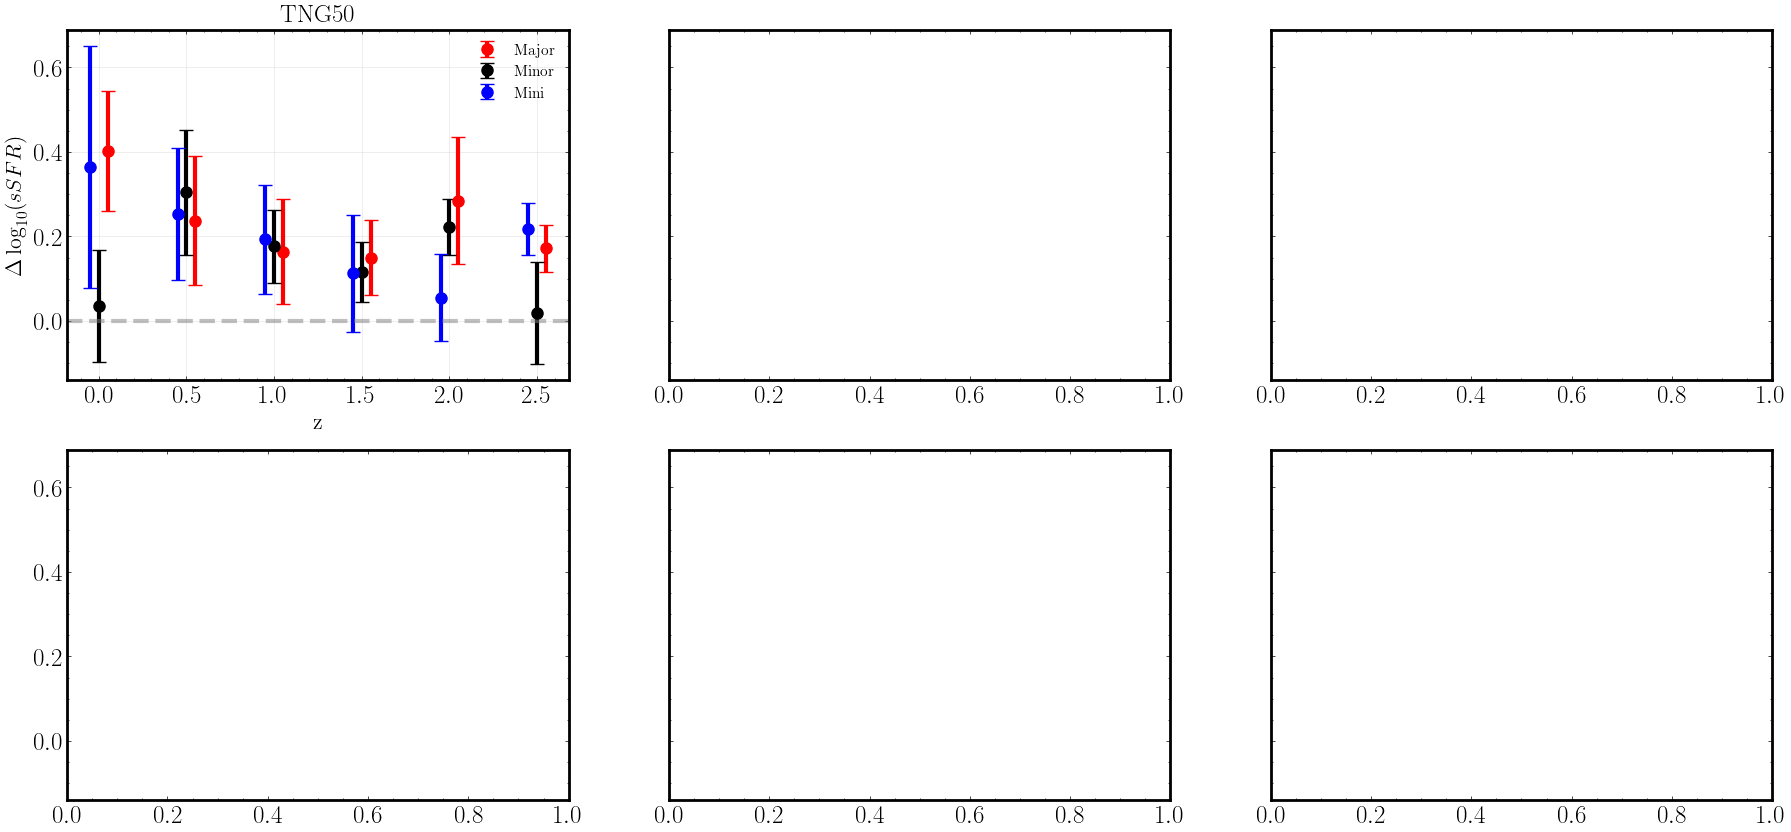

In [11]:
hostplot.set_plot_style(linewidth=3, titlesize=20,labelsize=18,xlabelsize=18,ylabelsize=18,legendsize=12)
fig,ax = plt.subplots(2,3,figsize=(22,10),sharey=True)
ax = ax.flatten()

sim_list = ['TNG50','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG']
z_offset = 0.05

for idx, sim in enumerate(sim_list):
    z_start = 0 if sim == 'TNG50' else 0
    zbin = 0.5 if sim == 'TNG50' else zbin_brahma[sim]
    zend = 4 if sim == 'TNG50' else zend_brahma[sim]
    Nmin = 10 if sim == 'TNG50' else 5
    
    z_bins,avg_sSFR_major,std_sSFR_major,avg_sSFR_minor,std_sSFR_minor,avg_sSFR_mini,std_sSFR_mini = merger_enhancement_calc_for_mu(
        sim_objs[sim],'sSFR',log=True,z_start=z_start,zbin=zbin,zend=zend,Nmin=Nmin)
    
    ax[idx].errorbar(np.array(z_bins[:-1])+z_offset,avg_sSFR_major,yerr=std_sSFR_major,
                     fmt='o',color='red',capsize=5,label='Major',markersize=8)
    ax[idx].errorbar(np.array(z_bins[:-1]),avg_sSFR_minor,yerr=std_sSFR_minor,
                     fmt='o',color='black',capsize=5,label='Minor',markersize=8)
    ax[idx].errorbar(np.array(z_bins[:-1])-z_offset,avg_sSFR_mini,yerr=std_sSFR_mini,
                     fmt='o',color='blue',capsize=5,label='Mini',markersize=8)
    
    ax[idx].axhline(0,ls='--',color='grey',alpha=0.5)
    ax[idx].set_xlabel('z',fontsize=16)
    ax[idx].set_ylabel(r'$\Delta \log_{10}(sSFR)$',fontsize=16)
    ax[idx].set_title(sim,fontsize=18,fontweight='bold')
    ax[idx].legend(loc='best',fontsize=11)
    ax[idx].grid(True,alpha=0.3)

# Second row: sBHAR enhancement
for idx, sim in enumerate(sim_list):
    z_start = 0 if sim == 'TNG50' else 0
    zbin = 0.5 if sim == 'TNG50' else zbin_brahma[sim]
    zend = 4 if sim == 'TNG50' else zend_brahma[sim]
    Nmin = 10 if sim == 'TNG50' else 5
    
    z_bins,avg_sBHAR_major,std_sBHAR_major,avg_sBHAR_minor,std_sBHAR_minor,avg_sBHAR_mini,std_sBHAR_mini = merger_enhancement_calc_for_mu(
        sim_objs[sim],'sBHAR',log=True,z_start=z_start,zbin=zbin,zend=zend,Nmin=Nmin)
    
    ax[idx+3].errorbar(np.array(z_bins[:-1])+z_offset,avg_sBHAR_major,yerr=std_sBHAR_major,
                       fmt='o',color='red',capsize=5,label='Major',markersize=8)
    ax[idx+3].errorbar(np.array(z_bins[:-1]),avg_sBHAR_minor,yerr=std_sBHAR_minor,
                       fmt='o',color='black',capsize=5,label='Minor',markersize=8)
    ax[idx+3].errorbar(np.array(z_bins[:-1])-z_offset,avg_sBHAR_mini,yerr=std_sBHAR_mini,
                       fmt='o',color='blue',capsize=5,label='Mini',markersize=8)
    
    ax[idx+3].axhline(0,ls='--',color='grey',alpha=0.5)
    ax[idx+3].set_xlabel('z',fontsize=16)
    ax[idx+3].set_ylabel(r'$\Delta \log_{10}(sBHAR)$',fontsize=16)
    ax[idx+3].set_title(sim,fontsize=18,fontweight='bold')
    ax[idx+3].legend(loc='best',fontsize=11)
    ax[idx+3].grid(True,alpha=0.3)

#ax[5].remove()  # remove unused subplot
fig.tight_layout()
plt.show()

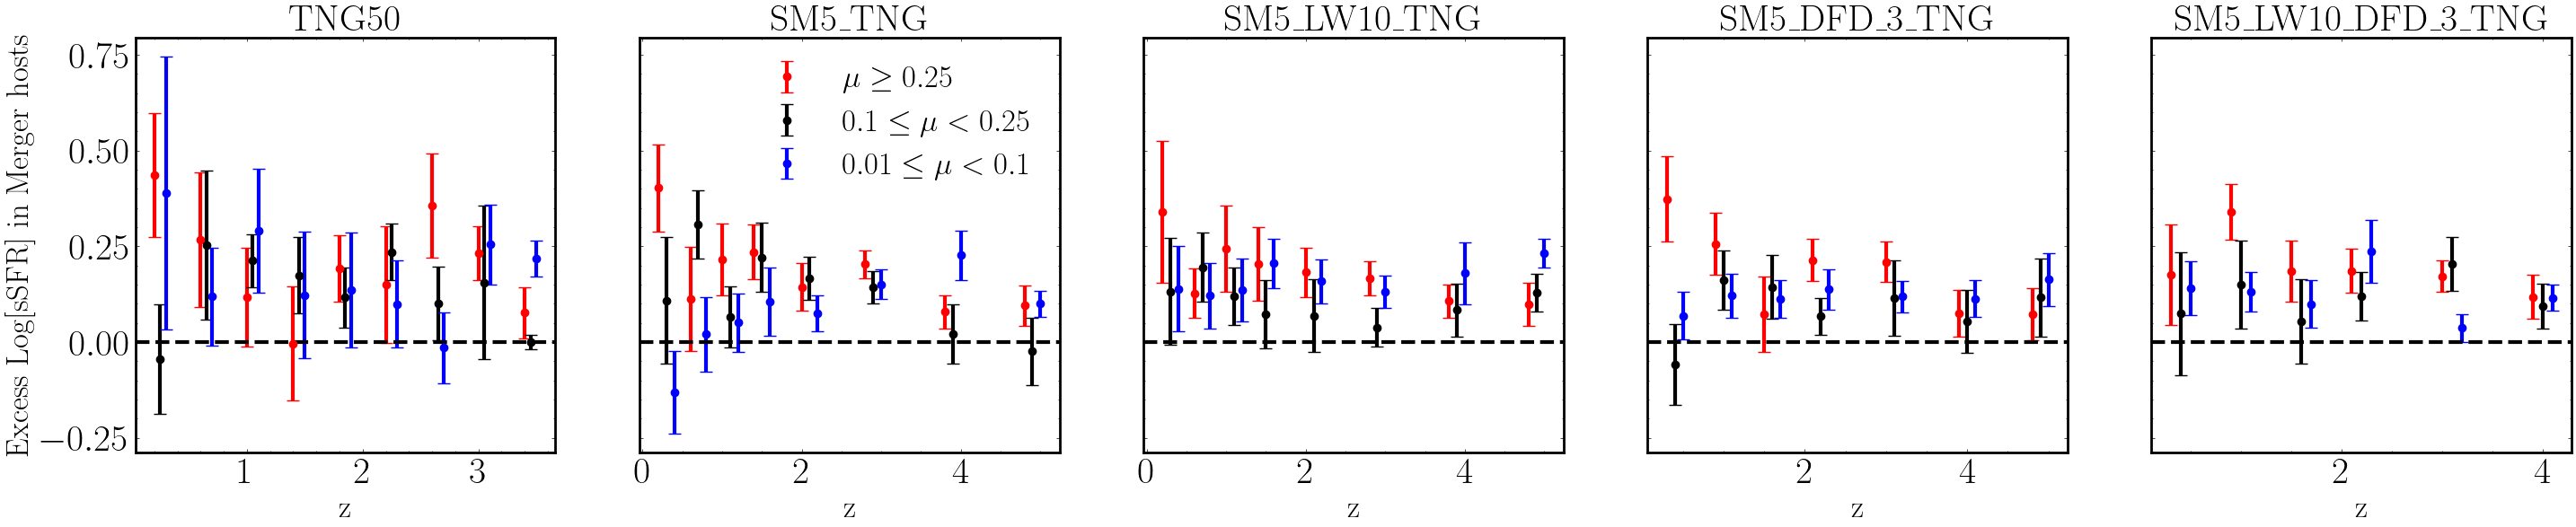

In [63]:
hostplot.set_plot_style(linewidth=3, titlesize=30,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=25)
fig,ax = plt.subplots(1,5,figsize=(35,6),sharey=True)
sim_markers = {'SM5_TNG': 'o', 'SM5_DFD_3_TNG': 's', 'SM5_LW10_TNG': '+', 'SM5_LW10_DFD_3_TNG': 'D', 'TNG50': '^'}

z_bins,avg_sSFR_major,std_sSFR_major,avg_sSFR_minor,std_sSFR_minor,avg_sSFR_mini,std_sSFR_mini = merger_enhancement_calc_for_mu(sim_objs['TNG50'],'sSFR',log=True,z_start=0,zbin=0.4,zend=4,Nmin=5)
z_offset = 0.05
ax[0].errorbar(z_bins[:-1]+np.diff(z_bins)/2,avg_sSFR_major,yerr=std_sSFR_major,fmt='o',capsize=5,label="$\\mu\\geq0.25$",color="red",alpha=1)
ax[0].errorbar(z_bins[:-1]+np.diff(z_bins)/2+z_offset,avg_sSFR_minor,yerr=std_sSFR_minor,fmt='o',capsize=5,label="$0.1\\leq\\mu<0.25$",color="black",alpha=1)
ax[0].errorbar(z_bins[:-1]+np.diff(z_bins)/2+2*z_offset,avg_sSFR_mini,yerr=std_sSFR_mini,fmt='o',capsize=5,label="$0.01\\leq\\mu<0.1$",color="blue",alpha=1)
ax[0].set_xlabel('z')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_title('TNG50')
ax[0].set_ylabel('Excess Log[sSFR] in Merger hosts')

zbin_brahma = {'SM5_TNG': 0.4, 'SM5_LW10_TNG': 0.4, 'SM5_DFD_3_TNG': 0.6, 'SM5_LW10_DFD_3_TNG': 0.6}
zend_brahma = {'SM5_TNG': 10, 'SM5_LW10_TNG': 10, 'SM5_DFD_3_TNG': 10, 'SM5_LW10_DFD_3_TNG': 10}
brahma_sim_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG']
for i,sim in enumerate(brahma_sim_array):
    z_bins,avg_sSFR_major,std_sSFR_major,avg_sSFR_minor,std_sSFR_minor,avg_sSFR_mini,std_sSFR_mini = merger_enhancement_calc_for_mu(sim_objs[sim],'sSFR',log=True,z_start=0,zbin=zbin_brahma[sim],zend=zend_brahma[sim],Nmin=5)
    z_offset = 0.1
    ax[i+1].errorbar(z_bins[:-1]+np.diff(z_bins)/2,avg_sSFR_major,yerr=std_sSFR_major,fmt='o',capsize=5,label="$\\mu\\geq0.25$",color="red",alpha=1)
    ax[i+1].errorbar(z_bins[:-1]+np.diff(z_bins)/2+z_offset,avg_sSFR_minor,yerr=std_sSFR_minor,fmt='o',capsize=5,label="$0.1\\leq\\mu<0.25$",color="black",alpha=1)
    ax[i+1].errorbar(z_bins[:-1]+np.diff(z_bins)/2+2*z_offset,avg_sSFR_mini,yerr=std_sSFR_mini,fmt='o',capsize=5,label="$0.01\\leq\\mu<0.1$",color="blue",alpha=1)
    ax[i+1].set_xlabel('z')
    ax[i+1].axhline(0,ls='--',color='black')
    ax[i+1].set_title(sim)
    if i==1:
        ax[i].legend()
# ...existing code...

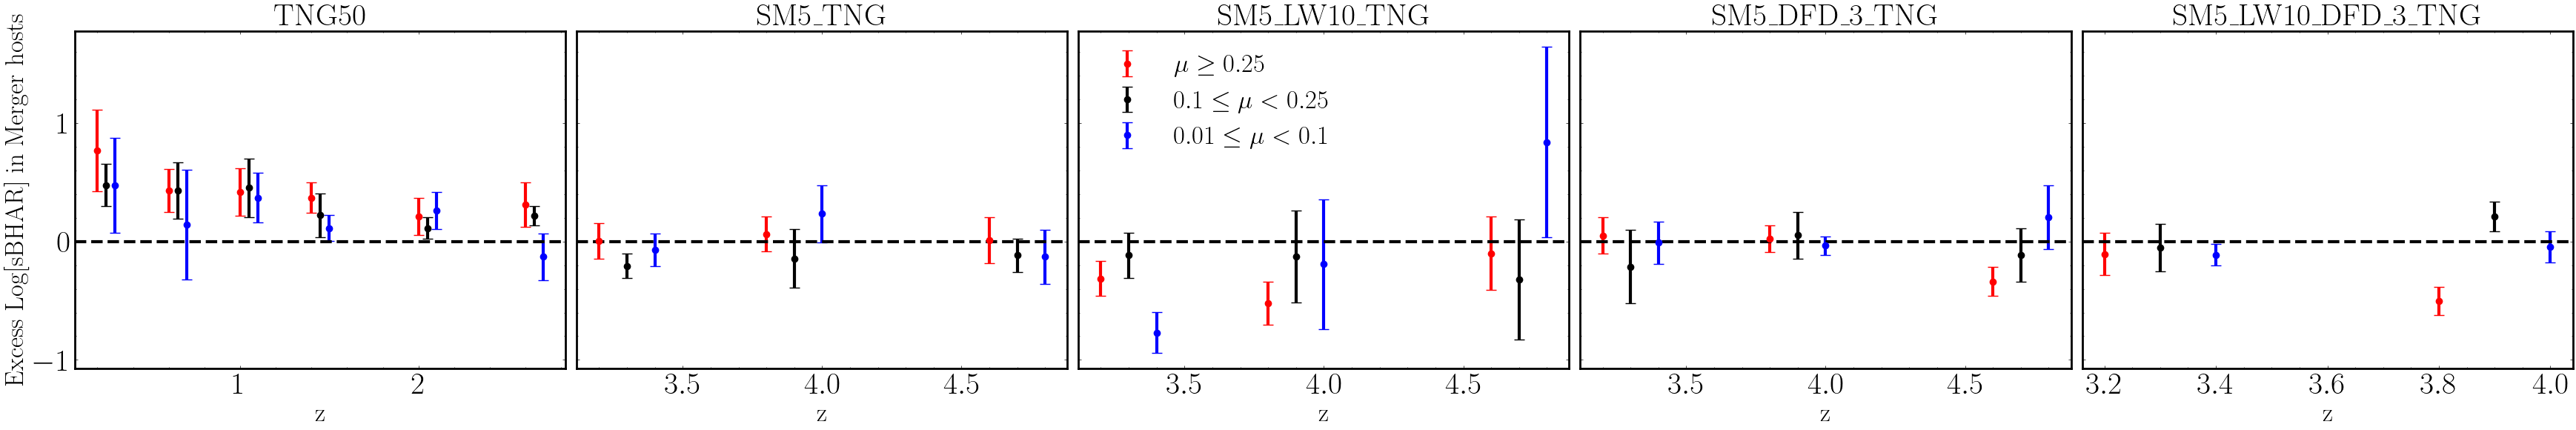

In [24]:
# ...existing code...
# sBHAR panel (same layout as sSFR)
hostplot.set_plot_style(linewidth=3, titlesize=30,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=25)
fig,ax = plt.subplots(1,5,figsize=(35,6),sharey=True)

# TNG50
z_bins,avg_sBHAR_major,std_sBHAR_major,avg_sBHAR_minor,std_sBHAR_minor,avg_sBHAR_mini,std_sBHAR_mini = merger_enhancement_calc_for_mu(sim_objs['TNG50'],'sBHAR',log=True,z_start=0,zbin=0.4,zend=4,Nmin=10)
z_offset = 0.05
ax[0].errorbar(z_bins[:-1]+np.diff(z_bins)/2,avg_sBHAR_major,yerr=std_sBHAR_major,fmt='o',capsize=5,label=r"$\mu\geq0.25$",color="red",alpha=1)
ax[0].errorbar(z_bins[:-1]+np.diff(z_bins)/2+z_offset,avg_sBHAR_minor,yerr=std_sBHAR_minor,fmt='o',capsize=5,label=r"$0.1\leq\mu<0.25$",color="black",alpha=1)
ax[0].errorbar(z_bins[:-1]+np.diff(z_bins)/2+2*z_offset,avg_sBHAR_mini,yerr=std_sBHAR_mini,fmt='o',capsize=5,label=r"$0.01\leq\mu<0.1$",color="blue",alpha=1)
ax[0].set_xlabel('z')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_title('TNG50')
ax[0].set_ylabel('Excess Log[sBHAR] in Merger hosts')

# BRAHMA sims
zbin_brahma = {'SM5_TNG': 0.4, 'SM5_LW10_TNG': 0.4, 'SM5_DFD_3_TNG': 0.4, 'SM5_LW10_DFD_3_TNG': 0.4}
zend_brahma = {'SM5_TNG': 10, 'SM5_LW10_TNG': 10, 'SM5_DFD_3_TNG': 10, 'SM5_LW10_DFD_3_TNG': 10}
brahma_sim_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG']

for i,sim in enumerate(brahma_sim_array):
    z_bins,avg_sBHAR_major,std_sBHAR_major,avg_sBHAR_minor,std_sBHAR_minor,avg_sBHAR_mini,std_sBHAR_mini = merger_enhancement_calc_for_mu(sim_objs[sim],'sBHAR',log=True,z_start=3,zbin=zbin_brahma[sim],zend=zend_brahma[sim],Nmin=5)
    z_offset = 0.1
    ax[i+1].errorbar(z_bins[:-1]+np.diff(z_bins)/2,avg_sBHAR_major,yerr=std_sBHAR_major,fmt='o',capsize=5,label=r"$\mu\geq0.25$",color="red",alpha=1)
    ax[i+1].errorbar(z_bins[:-1]+np.diff(z_bins)/2+z_offset,avg_sBHAR_minor,yerr=std_sBHAR_minor,fmt='o',capsize=5,label=r"$0.1\leq\mu<0.25$",color="black",alpha=1)
    ax[i+1].errorbar(z_bins[:-1]+np.diff(z_bins)/2+2*z_offset,avg_sBHAR_mini,yerr=std_sBHAR_mini,fmt='o',capsize=5,label=r"$0.01\leq\mu<0.1$",color="blue",alpha=1)
    ax[i+1].set_xlabel('z')
    ax[i+1].axhline(0,ls='--',color='black')
    ax[i+1].set_title(sim)
    if i==1:
        ax[i+1].legend()

fig.tight_layout()
fig.savefig("../../figures/sBHAR_excess_vs_z_mu_bins.pdf")
# ...existing code...